<a href="https://colab.research.google.com/github/ruveydakarakoyun/APTOS-2019/blob/main/aptos_2019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Veri Yükleme ve Kütüphaneleri Yükleme

In [29]:
import torch

print("PyTorch Versiyonu:", torch.__version__)
print("Mac M2 GPU (MPS) Kullanılabilir mi?:", torch.backends.mps.is_available())

PyTorch Versiyonu: 2.11.0+cpu
Mac M2 GPU (MPS) Kullanılabilir mi?: False


In [30]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("PyTorch Versiyonu:", torch.__version__)
print("🚀 Aktif Cihaz:", device)

if device.type == "cuda":
    print("GPU Adı:", torch.cuda.get_device_name(0))
elif device.type == "cpu":
    print("⚠️ GPU bulunamadı. Colab'da: Runtime → Change runtime type → Hardware accelerator → GPU seç.")

PyTorch Versiyonu: 2.11.0+cpu
🚀 Aktif Cihaz: cpu
⚠️ GPU bulunamadı. Colab'da: Runtime → Change runtime type → Hardware accelerator → GPU seç.


In [31]:
import torch

# Mac M2 (MPS), Nvidia (CUDA) ve CPU dinamik cihaz ataması
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🚀 Aktif Cihaz: Mac M2 Pro GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"🚀 Aktif Cihaz: Nvidia GPU ({torch.cuda.get_device_name(0)})")
else:
    device = torch.device("cpu")
    print("⚠️ Aktif Cihaz: CPU")

⚠️ Aktif Cihaz: CPU


In [32]:
# ==============================================================================
# 1. GEREKLİ KÜTÜPHANELER
# ==============================================================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# ==============================================================================
# 2. GPU / DEVICE KONTROLÜ
# ==============================================================================
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("PyTorch Versiyonu:", torch.__version__)
print("🚀 Aktif Cihaz:", device)

if device.type == "cuda":
    print("GPU Adı:", torch.cuda.get_device_name(0))
elif device.type == "cpu":
    print("⚠️ GPU bulunamadı, CPU ile devam edilecek (eğitim yavaş olabilir).")
    print("Colab'da: Üst menü → Runtime → Change runtime type → Hardware accelerator → GPU seç.")

# ==============================================================================
# 3. GOOGLE DRIVE BAĞLAMA (SADECE COLAB'DA ÇALIŞIR)
# ==============================================================================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print("✅ Google Drive bağlandı.")
except ImportError:
    IN_COLAB = False
    print("ℹ️ Colab ortamı değil, Drive bağlama atlandı.")

# ==============================================================================
# 4. VERİ YOLU AYARLARI
# ==============================================================================
# Kendi Drive klasör yapına göre bu satırı düzenle
DATA_DIR = "/content/drive/MyDrive/aptos2019" if IN_COLAB else "./data"

TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")

print("📁 Veri klasörü:", DATA_DIR)

PyTorch Versiyonu: 2.11.0+cpu
🚀 Aktif Cihaz: cpu
⚠️ GPU bulunamadı, CPU ile devam edilecek (eğitim yavaş olabilir).
Colab'da: Üst menü → Runtime → Change runtime type → Hardware accelerator → GPU seç.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive bağlandı.
📁 Veri klasörü: /content/drive/MyDrive/aptos2019


In [33]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# Yerel Dizin ve Veri Yolları Ayarları
# Verileri Colab veya yerel ortamda sakladığınız klasör yolu
DATA_DIR = "./data"  # Örn: Colab için "/content/aptos" veya yerel yol
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")

print("✅ Kütüphaneler ve yerel çalışma ortamı hazır!")

✅ Kütüphaneler ve yerel çalışma ortamı hazır!


###Tabloları Çekme

In [34]:
import os
import pandas as pd

# ==============================================================================
# PROJE GENEL YAPILANDIRMASI (DRIVE VERSİYONU)
# ==============================================================================
DATA_DIR = "/content/drive/MyDrive/aptos2019"

# Klasörler iç-içe (örn: train_images/train_images/*.png) olduğu için
# path'lerin sonuna klasör adını bir kez daha ekliyoruz
PATH_PREFIXES = {
    "train": os.path.join(DATA_DIR, "train_images", "train_images"),
    "valid": os.path.join(DATA_DIR, "val_images", "val_images"),
    "validation": os.path.join(DATA_DIR, "val_images", "val_images"),
    "test": os.path.join(DATA_DIR, "test_images", "test_images"),
}

# ==============================================================================
# CSV'DEN VERİLERİ OKUMA
# ==============================================================================
df_train = pd.read_csv(os.path.join(DATA_DIR, "train_1.csv"))
df_valid = pd.read_csv(os.path.join(DATA_DIR, "valid.csv"))
df_test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print(f"📊 Train Veri Sayısı : {len(df_train)}")
print(f"📊 Valid Veri Sayısı : {len(df_valid)}")
print(f"📊 Test Veri Sayısı  : {len(df_test)}")

print("\nTrain sütunları:", df_train.columns.tolist())
print(df_train.head())

# Yol doğrulama testi — ilk train görüntüsünün var olup olmadığını kontrol et
sample_id = df_train.iloc[0]["id_code"]
sample_path = os.path.join(PATH_PREFIXES["train"], f"{sample_id}.png")
print("\n🔍 Örnek dosya yolu:", sample_path)
print("Dosya var mı:", os.path.exists(sample_path))

📊 Train Veri Sayısı : 2930
📊 Valid Veri Sayısı : 366
📊 Test Veri Sayısı  : 366

Train sütunları: ['id_code', 'diagnosis']
        id_code  diagnosis
0  1ae8c165fd53          2
1  1b329a127307          1
2  1b32e1d775ea          4
3  1b3647865779          0
4  1b398c0494d1          0

🔍 Örnek dosya yolu: /content/drive/MyDrive/aptos2019/train_images/train_images/1ae8c165fd53.png
Dosya var mı: True


#EDA

###Sınıf dağılımı (Evre 0 - Evre 4 kaçar adet?) grafikleri ve Sınıf dengesizliği oranları


📊 Train Sınıf Dağılımı


,Evre,Sınıf,Görüntü Sayısı,Yüzde (%)
0,0,No DR,1434,48.94
1,1,Mild,300,10.24
2,2,Moderate,808,27.58
3,3,Severe,154,5.26
4,4,Proliferative DR,234,7.99


En fazla görüntü : Evre 0 (No DR) → 1434
En az görüntü   : Evre 3 (Severe) → 154
Sınıf dengesizlik oranı (Max / Min): 9.31


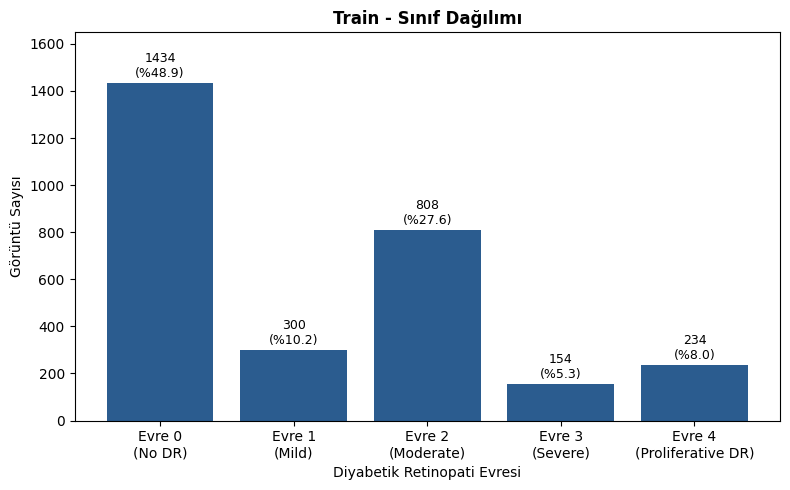


📊 Validation Sınıf Dağılımı


,Evre,Sınıf,Görüntü Sayısı,Yüzde (%)
0,0,No DR,172,46.99
1,1,Mild,40,10.93
2,2,Moderate,104,28.42
3,3,Severe,22,6.01
4,4,Proliferative DR,28,7.65


En fazla görüntü : Evre 0 (No DR) → 172
En az görüntü   : Evre 3 (Severe) → 22
Sınıf dengesizlik oranı (Max / Min): 7.82


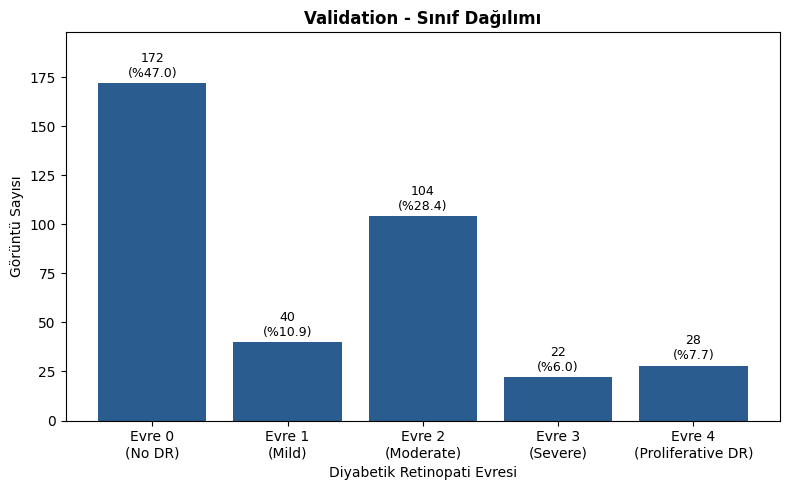


📊 Test Sınıf Dağılımı


,Evre,Sınıf,Görüntü Sayısı,Yüzde (%)
0,0,No DR,199,54.37
1,1,Mild,30,8.20
2,2,Moderate,87,23.77
3,3,Severe,17,4.64
4,4,Proliferative DR,33,9.02


En fazla görüntü : Evre 0 (No DR) → 199
En az görüntü   : Evre 3 (Severe) → 17
Sınıf dengesizlik oranı (Max / Min): 11.71


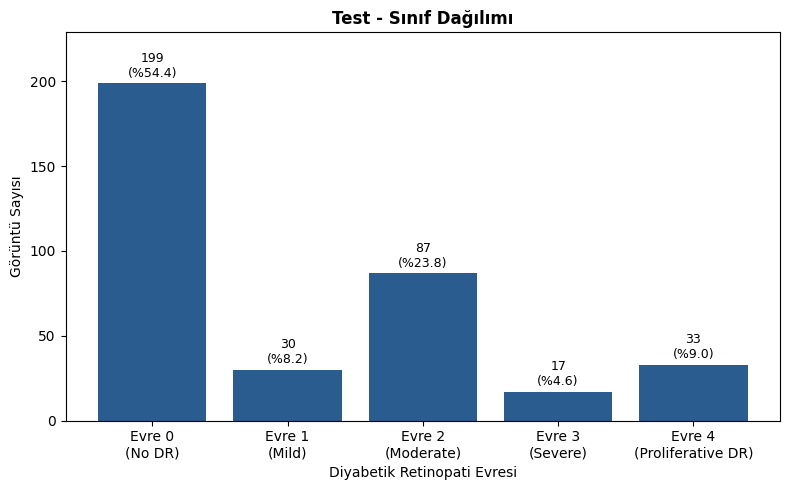

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Sınıf isimleri
class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}

datasets = {"Train": df_train, "Validation": df_valid, "Test": df_test}

for dataset_name, df in datasets.items():
    # Her sınıftaki görüntü sayısı
    counts = (
        df["diagnosis"]
        .value_counts()
        .reindex(range(5), fill_value=0)
        .sort_index()
    )

    # Yüzdelik dağılım
    percentages = (counts / counts.sum()) * 100

    # Sonuç tablosu
    distribution_table = pd.DataFrame({
        "Evre": counts.index,
        "Sınıf": [class_names[i] for i in counts.index],
        "Görüntü Sayısı": counts.values,
        "Yüzde (%)": percentages.round(2).values,
    })

    print(f"\n📊 {dataset_name} Sınıf Dağılımı")
    display(distribution_table)

    # Sınıf dengesizliği
    non_zero_counts = counts[counts > 0]
    max_count = non_zero_counts.max()
    min_count = non_zero_counts.min()
    imbalance_ratio = max_count / min_count

    print(
        f"En fazla görüntü : Evre {non_zero_counts.idxmax()} ({class_names[non_zero_counts.idxmax()]}) → {max_count}"
    )
    print(
        f"En az görüntü   : Evre {non_zero_counts.idxmin()} ({class_names[non_zero_counts.idxmin()]}) → {min_count}"
    )
    print(f"Sınıf dengesizlik oranı (Max / Min): {imbalance_ratio:.2f}")

    # Grafik
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(
        [f"Evre {i}\n({class_names[i]})" for i in counts.index],
        counts.values,
        color="#2b5c8f",
    )

    ax.set_title(
        f"{dataset_name} - Sınıf Dağılımı", fontsize=12, fontweight="bold"
    )
    ax.set_xlabel("Diyabetik Retinopati Evresi", fontsize=10)
    ax.set_ylabel("Görüntü Sayısı", fontsize=10)

    # Grafik üst limitini yazılar sığsın diye biraz artırıyoruz
    ax.set_ylim(0, max_count * 1.15)

    for bar, count, percentage in zip(bars, counts.values, percentages.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (max_count * 0.01),
            f"{count}\n(%{percentage:.1f})",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()
    plt.close(fig)  # Bellek temizliği

 ### Ham retina resimlerinin piksel boyutları, çözünürlükleri ve renk kanalları (RGB/Grayscale) kontrol edilir.

In [ ]:
import os
from PIL import Image
from tqdm.auto import tqdm
import pandas as pd
from IPython.display import display

# ==============================================================================
# GÖRÜNTÜ ÖZELLİKLERİ RAPORU (DRIVE VERSİYONU)
# ==============================================================================
CACHE_PATH = os.path.join(
    "/content/drive/MyDrive/aptos2019", "eda_cache", "image_properties.csv"
)


def generate_image_properties(df, folder_path, sample_size=None):
    """Görüntülerin boyut/kanal bilgisini tarayıp bir rapor DataFrame'i üretir."""
    records = []
    rows = df.head(sample_size) if sample_size else df

    for _, row in tqdm(
        rows.iterrows(), total=len(rows), desc="Görüntüler taranıyor"
    ):
        img_id = row["id_code"]
        img_path = os.path.join(folder_path, f"{img_id}.png")

        try:
            with Image.open(img_path)

In [ ]:
# Ham görüntü analizi özeti

print("📐 GÖRÜNTÜ BOYUTLARI")
display(
    image_properties_df[["width", "height"]].describe()
)

print("\n🖼️ TOPLAM FARKLI ÇÖZÜNÜRLÜK SAYISI")
print(image_properties_df["resolution"].nunique())

print("\n🖼️ EN SIK GÖRÜLEN 10 ÇÖZÜNÜRLÜK")
display(
    image_properties_df["resolution"]
    .value_counts()
    .head(10)
)

print("\n🎨 RENK MODLARI")
display(
    image_properties_df["color_mode"].value_counts()
)

print("\n📺 KANAL SAYILARI")
display(
    image_properties_df["channels"].value_counts()
)

📐 GÖRÜNTÜ BOYUTLARI


NameError: name 'image_properties_df' is not defined

Ham retina görüntülerinin çözünürlüklerinin sabit olmadığı ve veri setinde 17 farklı çözünürlük bulunduğu görülmüştür. Görüntü boyutları 474×358 ile 4288×2848 arasında değişmektedir. Tüm 3662 görüntünün RGB formatında ve 3 kanallı olduğu doğrulanmıştır. Bu nedenle modelleme öncesinde görüntülerin ortak bir boyuta yeniden ölçeklendirilmesi gerekmektedir.

### Veri Temizleme ve Kalite Kontrol Betiği

Bozuk, açılmayan veya aşırı karanlık görseller için hızlı bir veri temizleme kontrol betiği

In [ ]:
import os
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
from PIL import Image, ImageStat
from tqdm.auto import tqdm


def verify_single_image(row, folder_path, brightness_threshold):
    img_file = (
        row["image_file"]
        if "image_file" in row and pd.notnull(row["image_file"])
        else f"{row['id_code']}.png"
    )
    full_path = os.path.join(folder_path, img_file)

    try:
        img = Image.open(full_path).convert("RGB")

        # Parlaklık hesabı (Grayscale dönüşümü üzerinden ortalama piksel değeri)
        stat = ImageStat.Stat(img.convert("L"))
        mean_brightness = stat.mean[0]

        if mean_brightness < brightness_threshold:
            return ("dark", row["id_code"], full_path, mean_brightness)
        else:
            return ("valid", row.name, None, None)

    except Exception as e:
        return ("corrupted",

### Göz etrafındaki siyah boşlukları otomatik kesen Auto-Crop uygulama.

CLAHE :Kılcal damarları netleştirmek için CLAHE (Kontrast Artırma) algoritması kodlanır ve görsellere uygulanır

Orijinal boyut: (2136, 3216, 3)
Crop sonrası boyut: (2136, 2718, 3)


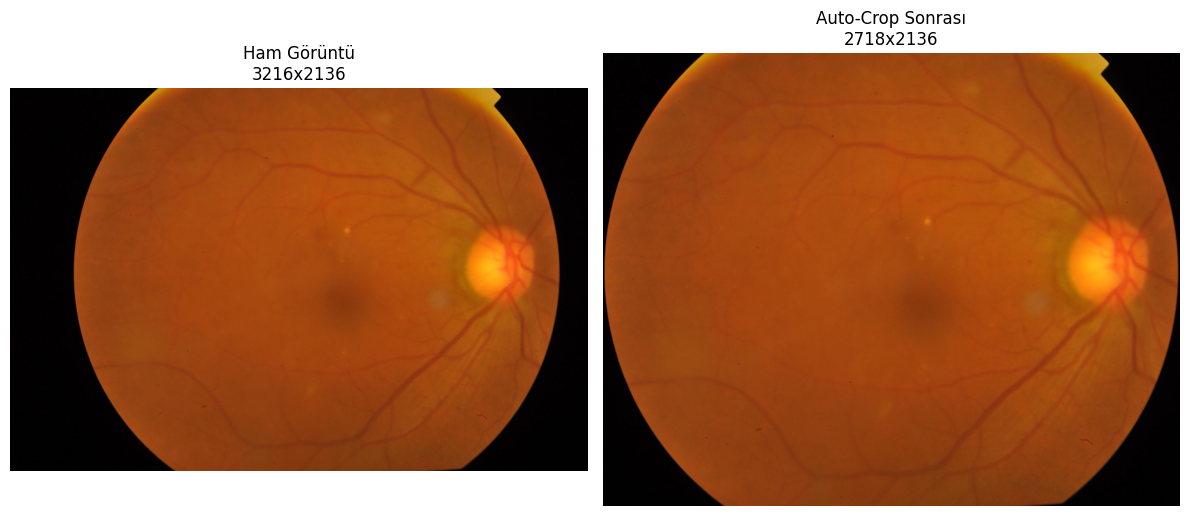

In [43]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms

# ==============================================================================
# PROJE YAPILANDIRMASI (DRIVE VERSİYONU)
# ==============================================================================
DATA_DIR = "/content/drive/MyDrive/aptos2019"

PATH_PREFIXES = {
    "train": os.path.join(DATA_DIR, "train_images", "train_images"),
    "valid": os.path.join(DATA_DIR, "val_images", "val_images"),
    "test": os.path.join(DATA_DIR, "test_images", "test_images"),
}


# ==============================================================================
# 1. ADIM: Auto-Crop Fonksiyonu
# ==============================================================================
def auto_crop(image, threshold=10, padding=5):
    if isinstance(image, Image.Image):
        image = np.array(image)

    gray = (
        cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        if len(image.shape) == 3
        else image
    )
    mask = gray > threshold

    if not np.any(mask):
        return image

    y_coords, x_coords = np.where(mask)
    x_min, y_min = max(0, x_coords.min() - padding), max(
        0, y_coords.min() - padding
    )
    x_max, y_max = min(image.shape[1], x_coords.max() + padding + 1), min(
        image.shape[0], y_coords.max() + padding + 1
    )

    cropped = image[y_min:y_max, x_min:x_max]

    # Güvenlik eşiği (%10 altı kırpılmayı engelle)
    if (
        cropped.shape[0] < image.shape[0] * 0.1
        or cropped.shape[1] < image.shape[1] * 0.1
    ):
        return image

    return cropped


# ==============================================================================
# 2. & 3. ADIM: Test ve Görselleştirme
# ==============================================================================
test_row = df_train.iloc[0]
test_id = str(test_row["id_code"])
img_file = (
    test_row["image_file"]
    if "image_file" in test_row and pd.notnull(test_row["image_file"])
    else f"{test_id}.png"
)

img_path = os.path.join(PATH_PREFIXES["train"], img_file)

img_pil = Image.open(img_path).convert("RGB")
original_image = np.array(img_pil)
cropped_image = auto_crop(original_image)

print("Orijinal boyut:", original_image.shape)
print("Crop sonrası boyut:", cropped_image.shape)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title(f"Ham Görüntü\n{original_image.shape[1]}x{original_image.shape[0]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped_image)
plt.title(
    f"Auto-Crop Sonrası\n{cropped_image.shape[1]}x{cropped_image.shape[0]}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

Auto-Crop görüntü boyutu: (2136, 2718, 3)
CLAHE görüntü boyutu    : (2136, 2718, 3)


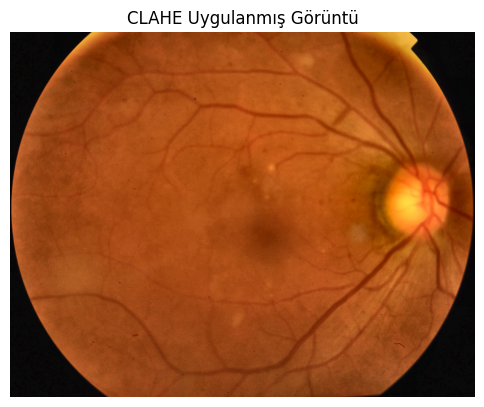

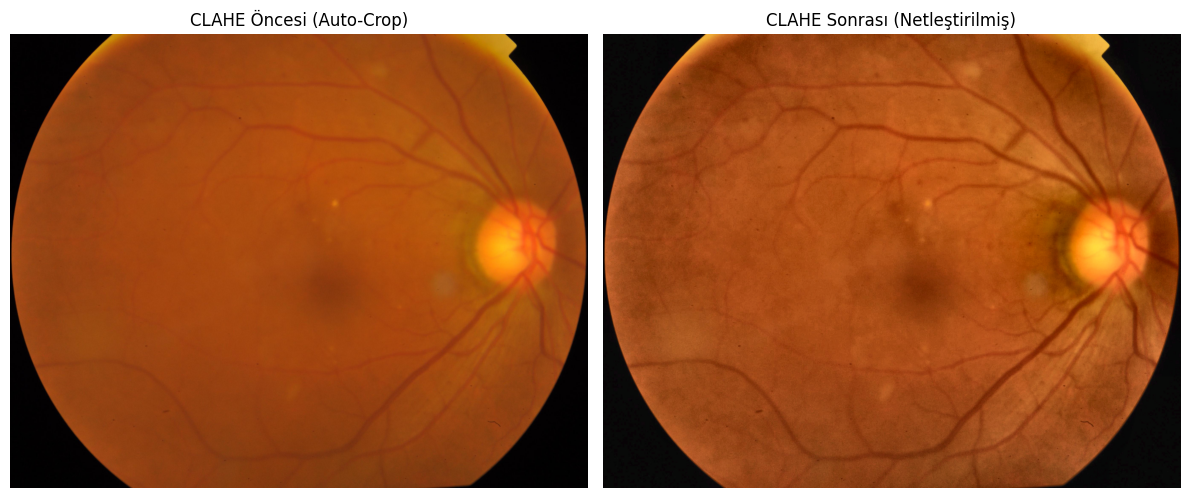

In [44]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


# ==============================================================================
# 1. CLAHE FONKSİYONU
# Retina görüntüsünde lokal kontrastı artırır
# ==============================================================================
def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    # RGB -> LAB
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    # L, A, B kanallarını ayır
    l, a, b = cv2.split(lab)

    # CLAHE oluştur
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    # Sadece parlaklık (L) kanalına CLAHE uygula
    l_clahe = clahe.apply(l)

    # Kanalları tekrar birleştir
    lab_clahe = cv2.merge((l_clahe, a, b))

    # LAB -> RGB
    enhanced_image = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

    return enhanced_image


# ==============================================================================
# 2. KARŞILAŞTIRMA FONKSİYONU
# CLAHE öncesi ve sonrası görüntüleri yan yana çizer
# ==============================================================================
def compare_clahe(before_image, after_image):
    plt.figure(figsize=(12, 5))

    # CLAHE öncesi
    plt.subplot(1, 2, 1)
    plt.imshow(before_image)
    plt.title("CLAHE Öncesi (Auto-Crop)")
    plt.axis("off")

    # CLAHE sonrası
    plt.subplot(1, 2, 2)
    plt.imshow(after_image)
    plt.title("CLAHE Sonrası (Netleştirilmiş)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ==============================================================================
# 3. UYGULAMA VE BOYUT KONTROLÜ
# ==============================================================================
# CLAHE uygulama
clahe_image = apply_clahe(cropped_image)

# Boyut Kontrolleri
print("Auto-Crop görüntü boyutu:", cropped_image.shape)
print("CLAHE görüntü boyutu    :", clahe_image.shape)

# Tekli Görselleştirme
plt.figure(figsize=(6, 6))
plt.imshow(clahe_image)
plt.title("CLAHE Uygulanmış Görüntü")
plt.axis("off")
plt.show()

# Karşılaştırmalı Görselleştirme
compare_clahe(cropped_image, clahe_image)

# PyTorch Dataset & Data Augmentation

### Albumentations kütüphanesi kullanılarak rastgele döndürme (rotation), yatay/dikey çevirme (flip) gibi Data Augmentation süreçleri (Eğitim (train) veri setinde çeşitliliği artırmak için güçlü dönüşümler eklerken, doğrulama (valid) veri setinde resimlerin orijinal yapısını koruyup sadece boyutlandırma ve normalize etme işlemleri uyguluyoruz)

In [45]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset


class APTOSDataset(Dataset):

    def __init__(self, df, folder_prefix="", transform=None):
        self.df = df.reset_index(drop=True)
        self.folder_prefix = folder_prefix
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_file = (
            row["image_file"]
            if "image_file" in row and pd.notnull(row["image_file"])
            else f"{row['id_code']}.png"
        )
        label = (
            int(row["diagnosis"])
            if "diagnosis" in row and pd.notnull(row["diagnosis"])
            else -1
        )

        img_path = os.path.join(self.folder_prefix, img_file)

        try:
            # 1. Yerel dosyadan PIL -> NumPy
            img_pil = Image.open(img_path).convert("RGB")
            img_np = np.array(img_pil)

            # 2. Auto-Crop Uygulaması
            img_cropped = auto_crop(img_np, threshold=10, padding=5)

            # 3. CLAHE Uygulaması (Kılcal damarları netleştirme)
            img_final = apply_clahe(img_cropped)

        except Exception:
            # Okuma hatasında 224x224 siyah görüntü fallback'i
            img_final = np.zeros((224, 224, 3), dtype=np.uint8)

        # 4. Albumentations Dönüşümü
        if self.transform:
            augmented = self.transform(image=img_final)
            img_tensor = augmented["image"]
        else:
            img_tensor = (
                torch.from_numpy(img_final).permute(2, 0, 1).float() / 255.0
            )

        return img_tensor, torch.tensor(label, dtype=torch.long)

In [46]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

# 1. Transform Tanımları
train_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5
        ),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

val_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

# 2. Dataset ve DataLoader Oluşturma
train_dataset = APTOSDataset(
    df=df_train,
    folder_prefix=PATH_PREFIXES["train"],
    transform=train_transform,
)

train_loader = DataLoader(
    train_dataset, batch_size=16, shuffle=True, num_workers=0
)

# 3. İlk Batch Kontrolü
images, labels = next(iter(train_loader))

print("✅ Albumentations Entegrasyonu Başarılı!")
print(f"📦 Batch Görüntü Şekli (Tensor) : {images.shape}")  # [16, 3, 224, 224]
print(f"🏷️ Batch Etiket Şekli (Tensor)  : {labels.shape}")  # [16]
print(f"📊 Veri Tipi                    : {images.dtype}")  # torch.float32

✅ Albumentations Entegrasyonu Başarılı!
📦 Batch Görüntü Şekli (Tensor) : torch.Size([16, 3, 224, 224])
🏷️ Batch Etiket Şekli (Tensor)  : torch.Size([16])
📊 Veri Tipi                    : torch.float32


** Albumentations kütüphanesi standart PIL görselleri yerine NumPy dizileri (np.ndarray) ile çalışır. Bu yüzden __getitem__ içinde kırpma işleminden sonra resmi NumPy formatında tutup transform(image=img_cropped) şeklinde çağırmamız gerekir

In [47]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset


class APTOSDataset(Dataset):

    def __init__(self, df, folder_prefix="", transform=None):
        self.df = df.reset_index(drop=True)
        self.folder_prefix = folder_prefix
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_file = (
            row["image_file"]
            if "image_file" in row and pd.notnull(row["image_file"])
            else f"{row['id_code']}.png"
        )
        label = (
            int(row["diagnosis"])
            if "diagnosis" in row and pd.notnull(row["diagnosis"])
            else -1
        )

        # 1. Yerel dosyadan resmi okuma
        img_path = os.path.join(self.folder_prefix, img_file)

        try:
            # 2. PIL -> NumPy (Albumentations için np.ndarray şarttır)
            img_pil = Image.open(img_path).convert("RGB")
            img_np = np.array(img_pil)

            # 3. Kırpma işlemi (Auto-Crop)
            img_cropped = auto_crop(img_np, threshold=10, padding=5)

            # 4. Kılcal Damarları Netleştirme (CLAHE)
            img_final = apply_clahe(img_cropped)

        except Exception:
            # Görsel okuma hatası olursa 224x224 siyah görüntü oluştur
            img_final = np.zeros((224, 224, 3), dtype=np.uint8)

        # 5. Albumentations Augmentation Uygulama
        if self.transform:
            augmented = self.transform(image=img_final)
            img_tensor = augmented["image"]
        else:
            img_tensor = (
                torch.from_numpy(img_final).permute(2, 0, 1).float() / 255.0
            )

        return img_tensor, torch.tensor(label, dtype=torch.long)

###PyTorch Dataset ve DataLoader sınıfları kodlanır.

####DataDataLoader'ları Hazırlama

###Eğitim, doğrulama (validation) ve test veri yükleyicilerinin sorunsuz veri beslediği test etme

✅ Train Loader: 2930 resim | 92 batch
✅ Val Loader  : 366 resim | 12 batch
✅ Test Loader : 366 resim | 12 batch

✅ VERİ BORUSU TESTİ BAŞARILI!
• Batch Resim Boyutu (Shape) : torch.Size([32, 3, 224, 224])
• Batch Etiket Boyutu (Shape): torch.Size([32])
• Veri Tipi (Dtype)          : torch.float32
• Etiket Örnekleri (İlk 5)   : [0, 2, 0, 0, 2]


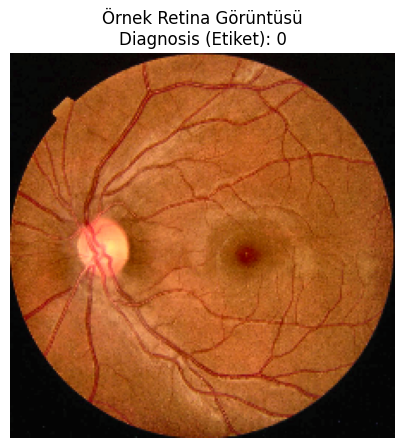

In [48]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

# ==============================================================================
# 1. DATALOADER'LARI TANIMLAMA
# ==============================================================================
num_workers = 0

# Train Dataset & Loader
train_dataset = APTOSDataset(
    df=df_train,
    folder_prefix=PATH_PREFIXES["train"],
    transform=train_transform,
)

# Validation Dataset & Loader
val_dataset = APTOSDataset(
    df=df_valid,
    folder_prefix=PATH_PREFIXES["valid"],
    transform=val_transform,
)

# Test Dataset & Loader
test_dataset = APTOSDataset(
    df=df_test,
    folder_prefix=PATH_PREFIXES["test"],
    transform=val_transform,
)

# DataLoader Yükleyicileri (Batch Size: 32)
train_loader = DataLoader(
    train_dataset, batch_size=32, shuffle=True, num_workers=num_workers
)
val_loader = DataLoader(
    val_dataset, batch_size=32, shuffle=False, num_workers=num_workers
)
test_loader = DataLoader(
    test_dataset, batch_size=32, shuffle=False, num_workers=num_workers
)

print(
    f"✅ Train Loader: {len(train_dataset)} resim | {len(train_loader)} batch"
)
print(f"✅ Val Loader  : {len(val_dataset)} resim | {len(val_loader)} batch")
print(f"✅ Test Loader : {len(test_dataset)} resim | {len(test_loader)} batch\n")

# ==============================================================================
# 2. VERİ BORUSU DOĞRULAMA VE GÖRSELLEŞTİRME TESTİ
# ==============================================================================
try:
    images, labels = next(iter(train_loader))

    print("✅ VERİ BORUSU TESTİ BAŞARILI!")
    print(f"• Batch Resim Boyutu (Shape) : {images.shape}")  # [32, 3, 224, 224]
    print(f"• Batch Etiket Boyutu (Shape): {labels.shape}")  # [32]
    print(f"• Veri Tipi (Dtype)          : {images.dtype}")
    print(f"• Etiket Örnekleri (İlk 5)   : {labels[:5].tolist()}")

    sample_img = images[0].permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    sample_img = std * sample_img + mean
    sample_img = np.clip(sample_img, 0, 1)

    plt.figure(figsize=(5, 5))
    plt.imshow(sample_img)
    plt.title(f"Örnek Retina Görüntüsü\nDiagnosis (Etiket): {labels[0].item()}")
    plt.axis("off")
    plt.show()

except Exception as e:
    print("❌ Data Borusu Testinde Hata Oluştu:")
    print(e)

# Model Mimarisi & Kayıp Fonksiyonu (Loss)

## Baseline (temel) basit bir custom CNN veya hafif model mimarisi hazırlama

## Baseline Modeli Test Etme (Dry Run)
Modelin beklenen girdi boyutlarını alıp sorunsuz çıktı verip vermediğini test etmek için train_loader'dan tek bir batch geçirerek doğrulayalım:

In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ==============================================================================
# BASELINE CUSTOM CNN MİMARİSİ
# ==============================================================================
class BaselineCNN(nn.Module):

    def __init__(self, num_classes=5):
        super(BaselineCNN, self).__init__()

        # 1. Evrişim (Convolution) Katmanları
        # Giriş Boyutu: [Batch, 3, 224, 224]
        self.conv1 = nn.Conv2d(
            in_channels=3, out_channels=16, kernel_size=3, padding=1
        )
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(
            in_channels=16, out_channels=32, kernel_size=3, padding=1
        )
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(
            in_channels=32, out_channels=64, kernel_size=3, padding=1
        )
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Boyutu yarıya indirir

        # Hesaplama: 224 -> Pool1 -> 112 -> Pool2 -> 56 -> Pool3 -> 28
        # Düzleştirilmiş Vektör: 64 * 28 * 28 = 50,176

        # 2. Tam Bağlantılı (Classifier) Katmanlar
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # [Batch, 16, 112, 112]
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # [Batch, 32, 56, 56]
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # [Batch, 64, 28, 28]

        # Flatten (Düzleştirme)
        x = x.view(x.size(0), -1)

        # Sınıflandırma
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


# ==============================================================================
# OTOMATİK CİHAZ SEÇİMİ (CUDA / MPS / CPU)
# ==============================================================================
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

baseline_model = BaselineCNN(num_classes=5).to(device)

print(f"✅ Baseline Custom CNN hazırlandı!")
print(f"🚀 Aktif Cihaz: {device}")

✅ Baseline Custom CNN hazırlandı!
🚀 Aktif Cihaz: cpu


### Baseline Modeli Test Etme (Dry Run)
Modelin beklenen girdi boyutlarını alıp sorunsuz çıktı verip vermediğini test etmek için train_loader'dan tek bir batch geçirerek doğrulayalım:

In [50]:
# Modeli sahte/test verisiyle kontrol etme (SMOKE TESTİ)
images, labels = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    outputs = baseline_model(images)

print(f"• Girdi Batch Boyutu : {images.shape}")   # [32, 3, 224, 224]
print(f"• Çıktı Batch Boyutu : {outputs.shape}")  # [32, 5] (32 resim için 5 sınıf skoru)
print("✅ Baseline model sorunsuz ileri besleme (forward pass) yapıyor!")

• Girdi Batch Boyutu : torch.Size([32, 3, 224, 224])
• Çıktı Batch Boyutu : torch.Size([32, 5])
✅ Baseline model sorunsuz ileri besleme (forward pass) yapıyor!


##Torchvision veya timm üzerinden EfficientNet-B0 ve ResNet50 modelleri çağrılır, son çıktı katmanları 5 sınıfa uyarlanır. Sınıf dengesizliği için Weighted Cross-Entropy ağırlıkları hesaplanır.

In [51]:
# ============================================================
# EfficientNet-B0 + ResNet50
# 5 sınıfa uyarlama + Weighted Cross-Entropy
# ============================================================

import torch
import torch.nn as nn

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights,
    resnet50,
    ResNet50_Weights
)

# Cihaz
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

NUM_CLASSES = 5

print("Kullanılan cihaz:", device)


# ============================================================
# 1. SINIF AĞIRLIKLARINI HESAPLA
# ============================================================

# Sadece TRAIN seti kullanılmalı
class_counts = (
    df_train["diagnosis"]
    .value_counts()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .sort_index()
)

print("\nTrain sınıf dağılımı:")
print(class_counts)


# Weighted Cross-Entropy için ağırlık:
# total_samples / (num_classes * class_count)

total_samples = class_counts.sum()

class_weights = (
    total_samples /
    (NUM_CLASSES * class_counts.values)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("\nSınıf ağırlıkları:")
for i, weight in enumerate(class_weights):
    print(f"Evre {i}: {weight.item():.4f}")


# ============================================================
# 2. WEIGHTED CROSS-ENTROPY LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("\n✅ Weighted Cross-Entropy Loss hazır.")


# ============================================================
# 3. EFFICIENTNET-B0
# ============================================================

efficientnet_model = efficientnet_b0(
    weights=EfficientNet_B0_Weights.DEFAULT
)

# EfficientNet-B0'nun son Linear katmanının giriş boyutu
efficientnet_in_features = (
    efficientnet_model.classifier[1].in_features
)

# Son katmanı 5 sınıfa çevir
efficientnet_model.classifier[1] = nn.Linear(
    efficientnet_in_features,
    NUM_CLASSES
)

efficientnet_model = efficientnet_model.to(device)

print("✅ EfficientNet-B0 hazır: çıktı sınıfı = 5")


# ============================================================
# 4. RESNET50
# ============================================================

resnet50_model = resnet50(
    weights=ResNet50_Weights.DEFAULT
)

# ResNet50'nin son FC katmanının giriş boyutu
resnet_in_features = resnet50_model.fc.in_features

# Son katmanı 5 sınıfa çevir
resnet50_model.fc = nn.Linear(
    resnet_in_features,
    NUM_CLASSES
)

resnet50_model = resnet50_model.to(device)

print("✅ ResNet50 hazır: çıktı sınıfı = 5")

Kullanılan cihaz: cpu

Train sınıf dağılımı:
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64

Sınıf ağırlıkları:
Evre 0: 0.4086
Evre 1: 1.9533
Evre 2: 0.7252
Evre 3: 3.8052
Evre 4: 2.5043

✅ Weighted Cross-Entropy Loss hazır.
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 399MB/s]


✅ EfficientNet-B0 hazır: çıktı sınıfı = 5
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 308MB/s]

✅ ResNet50 hazır: çıktı sınıfı = 5


In [53]:
# Model çıktı boyutlarını test et

dummy_input = torch.randn(
    2, 3, 224, 224
).to(device)

efficientnet_model.eval()
resnet50_model.eval()

with torch.no_grad():

    eff_output = efficientnet_model(dummy_input)
    res_output = resnet50_model(dummy_input)

print(
    "EfficientNet-B0 çıktı:",
    eff_output.shape
)

print(
    "ResNet50 çıktı:",
    res_output.shape
)

EfficientNet-B0 çıktı: torch.Size([2, 5])
ResNet50 çıktı: torch.Size([2, 5])


###EfficientNet-B0, ResNet50 ve Weighted Cross-Entropy
Bu aşamada transfer learning yaklaşımı kullanılarak torchvision üzerinden önceden eğitilmiş EfficientNet-B0 ve ResNet50 modelleri projeye dahil edilmiştir. Her iki modelin son sınıflandırma katmanı, diyabetik retinopati veri setindeki 5 sınıfı (Evre 0–4) tahmin edecek şekilde yeniden düzenlenmiştir.

Eğitim veri setinde belirgin sınıf dengesizliği bulunduğu için yalnızca eğitim verisindeki sınıf frekansları kullanılarak sınıf ağırlıkları hesaplanmıştır. Bu ağırlıklar Weighted Cross-Entropy Loss fonksiyonuna aktarılmış ve az örneğe sahip sınıflardaki hataların eğitim sırasında daha fazla dikkate alınması amaçlanmıştır.



##Model değerlendirme metrikleri için fonksiyonlar yazılır: Accuracy, Precision, Recall ve QWK (Quadratic Weighted Kappa)

In [54]:
# ============================================================

# MODEL DEĞERLENDİRME METRİKLERİ

# Accuracy, Precision, Recall ve QWK

# ============================================================



from sklearn.metrics import (

accuracy_score,

precision_score,

recall_score,

cohen_kappa_score

)





def calculate_metrics(y_true, y_pred):

    # Accuracy
    accuracy = accuracy_score(

    y_true,

    y_pred

    )



    # Precision
    # Sınıf dengesizliği nedeniyle macro average kullanıyoruz
    precision = precision_score(

    y_true,

    y_pred,

    average="macro",

    zero_division=0

    )



    # Recall
    recall = recall_score(

    y_true,

    y_pred,

    average="macro",

    zero_division=0

    )



    # Quadratic Weighted Kappa
    qwk = cohen_kappa_score(

    y_true,

    y_pred,

    weights="quadratic"

    )



    metrics = {

    "Accuracy": accuracy,

    "Precision": precision,

    "Recall": recall,

    "QWK": qwk

    }

    return metrics

In [55]:
import torch


def evaluate_model_performance(model, dataloader, device):
    """Modelden tahminleri toplar ve hesaplanan metrikleri döner."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            # Güvenli kullanım için cpu().numpy()
            all_labels.extend(labels.cpu().numpy())

    # Önceki hücrede tanımladığınız metrik fonksiyonunu çağırır
    metrics = calculate_metrics(all_labels, all_preds)
    return metrics, all_labels, all_preds

In [56]:
# Metrik fonksiyonunu hızlı test et

y_true_test = [0, 1, 2, 3, 4, 2, 0, 1]
y_pred_test = [0, 1, 2, 2, 4, 2, 0, 0]

test_metrics = calculate_metrics(
    y_true_test,
    y_pred_test
)

print("✅ Metrik fonksiyonları çalışıyor.\n")

for metric_name, value in test_metrics.items():
    print(
        f"{metric_name}: {value:.4f}"
    )

✅ Metrik fonksiyonları çalışıyor.

Accuracy: 0.7500
Precision: 0.6667
Recall: 0.7000
QWK: 0.9292


### Model Değerlendirme Metrikleri

Model performansını yalnızca doğruluk oranı üzerinden değerlendirmek yerine, sınıf dengesizliğini ve diyabetik retinopati evrelerinin sıralı yapısını dikkate alan bir değerlendirme altyapısı hazırlanmıştır.

Bu kapsamda **Accuracy**, **Macro Precision**, **Macro Recall** ve **Quadratic Weighted Kappa (QWK)** metriklerini hesaplayan bir fonksiyon oluşturulmuştur.

`Macro Precision` ve `Macro Recall`, her sınıfa eşit önem vererek özellikle az örneğe sahip sınıfların performansının da değerlendirmeye dahil edilmesini sağlar. `QWK` metriği ise sınıfların 0'dan 4'e sıralı yapısını dikkate alarak, tahmin edilen sınıf ile gerçek sınıf arasındaki hata büyüklüğünü değerlendirir.

Bu metrikler daha sonraki aşamalarda EfficientNet-B0, ResNet50 ve diğer modellerin performanslarını karşılaştırmak için kullanılacaktır.

In [ ]:
import os

# Checkpoint'leri Drive'da kalıcı bir klasöre kaydet (Colab oturumu kapanınca kaybolmasın)
CHECKPOINT_DIR = "/content/drive/MyDrive/aptos2019/checkpoints"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("✅ Model kayıt klasörü hazır:")
print(CHECKPOINT_DIR)

✅ Model kayıt klasörü hazır:
/content/drive/MyDrive/aptos2019/checkpoints


In [ ]:
import os
import torch
import matplotlib.pyplot as plt

from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from IPython.display import clear_output


def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    criterion,
    device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=True
):

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------
    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    # --------------------------------------------------------
    # Learning Rate Scheduler
    # Validation loss gelişmezse learning rate düşürülür
    # --------------------------------------------------------
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    # --------------------------------------------------------
    # Model kayıt yolları
    # --------------------------------------------------------
    best_model_path = os.path.join(
        CHECKPOINT_DIR,
        f"{model_name}_best_model.pth"
    )

    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        f"{model_name}_last_checkpoint.pth"
    )

    # --------------------------------------------------------
    # Başlangıç değerleri
    # --------------------------------------------------------
    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    early_stop_counter = 0
    start_epoch = 0

    # --------------------------------------------------------
    # Önceden yarım kalmış eğitim varsa devam et
    # --------------------------------------------------------
    if resume and os.path.exists(checkpoint_path):

        print("♻️ Önceki checkpoint bulundu.")

        checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=False
        )

        model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

        scheduler.load_state_dict(
            checkpoint["scheduler_state_dict"]
        )

        start_epoch = checkpoint["epoch"] + 1

        best_val_loss = checkpoint["best_val_loss"]

        train_losses = checkpoint.get(
            "train_losses",
            []
        )

        val_losses = checkpoint.get(
            "val_losses",
            []
        )

        early_stop_counter = checkpoint.get(
            "early_stop_counter",
            0
        )

        print(
            f"✅ Eğitim Epoch {start_epoch + 1}'den "
            f"devam edecek."
        )

    # ========================================================
    # EĞİTİM DÖNGÜSÜ
    # ========================================================
    for epoch in range(start_epoch, num_epochs):

        # ====================================================
        # TRAIN
        # ====================================================
        model.train()

        running_train_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Önceki gradientleri temizle
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Model ağırlıklarını güncelle
            optimizer.step()

            running_train_loss += (
                loss.item() * images.size(0)
            )

        train_loss = (
            running_train_loss /
            len(train_loader.dataset)
        )

        # ====================================================
        # VALIDATION
        # ====================================================
        model.eval()

        running_val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                running_val_loss += (
                    loss.item() * images.size(0)
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                correct += (
                    predictions == labels
                ).sum().item()

                total += labels.size(0)

        val_loss = (
            running_val_loss /
            len(val_loader.dataset)
        )

        val_accuracy = correct / total

        # ----------------------------------------------------
        # Loss geçmişi
        # ----------------------------------------------------
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # ----------------------------------------------------
        # Learning Rate Scheduler
        # ----------------------------------------------------
        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        # ====================================================
        # EN İYİ MODELİ KAYDET
        # ====================================================
        if val_loss < best_val_loss:

            best_val_loss = val_loss
            early_stop_counter = 0

            torch.save(
                model.state_dict(),
                best_model_path
            )

            model_status = "💾 Yeni en iyi model kaydedildi."

        else:

            early_stop_counter += 1

            model_status = (
                f"Early Stopping sayacı: "
                f"{early_stop_counter}/"
                f"{early_stopping_patience}"
            )

        # ====================================================
        # HER EPOCH SONUNDA CHECKPOINT
        # ====================================================
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "best_val_loss":
                    best_val_loss,

                "train_losses":
                    train_losses,

                "val_losses":
                    val_losses,

                "early_stop_counter":
                    early_stop_counter
            },
            checkpoint_path
        )

        # ====================================================
        # ANLIK LOSS GRAFİĞİ
        # ====================================================
        clear_output(wait=True)

        print(f"Model: {model_name}")
        print(f"Epoch: {epoch + 1}/{num_epochs}")
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Accuracy: {val_accuracy:.4f}")
        print(f"Learning Rate: {current_lr:.7f}")
        print(model_status)

        plt.figure(figsize=(8, 5))

        epoch_range = range(
            1,
            len(train_losses) + 1
        )

        plt.plot(
            epoch_range,
            train_losses,
            marker="o",
            label="Training Loss"
        )

        plt.plot(
            epoch_range,
            val_losses,
            marker="o",
            label="Validation Loss"
        )

        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(
            f"{model_name} - Training / Validation Loss"
        )

        plt.legend()
        plt.grid()
        plt.show()

        # ====================================================
        # EARLY STOPPING
        # ====================================================
        if (
            early_stop_counter
            >= early_stopping_patience
        ):

            print("\n🛑 Early Stopping devreye girdi.")
            print(
                "Validation loss iyileşmediği için "
                "eğitim erken durduruldu."
            )

            break

    # ========================================================
    # EN İYİ MODELİ GERİ YÜKLE
    # ========================================================
    model.load_state_dict(
        torch.load(
            best_model_path,
            map_location=device,
            weights_only=True
        )
    )

    print("\n✅ Eğitim tamamlandı.")
    print("En iyi Validation Loss:", round(best_val_loss, 4))
    print("En iyi model:", best_model_path)
    print("Son checkpoint:", checkpoint_path)

    return model, train_losses, val_losses

Model: efficientnet_b0
Epoch: 10/15
Train Loss : 0.4054
Val Loss   : 0.9317
Val Accuracy: 0.8087
Learning Rate: 0.0000500
Early Stopping sayacı: 4/4


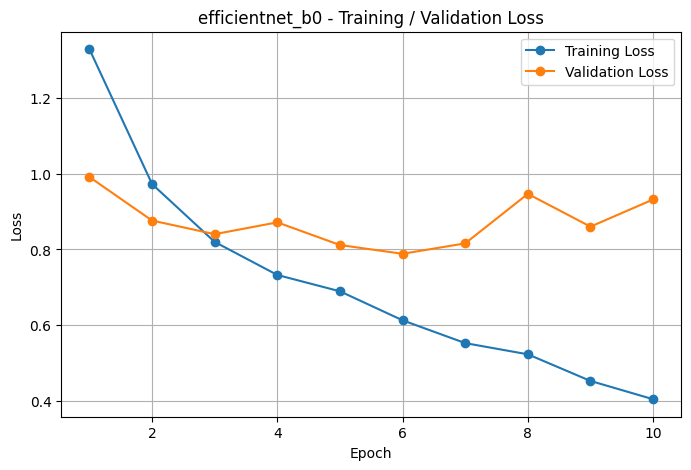


🛑 Early Stopping devreye girdi.
Validation loss iyileşmediği için eğitim erken durduruldu.

✅ Eğitim tamamlandı.
En iyi Validation Loss: 0.7886
En iyi model: /content/drive/MyDrive/aptos2019/checkpoints/efficientnet_b0_best_model.pth
Son checkpoint: /content/drive/MyDrive/aptos2019/checkpoints/efficientnet_b0_last_checkpoint.pth


In [ ]:
efficientnet_model, eff_train_losses, eff_val_losses = train_model(
    model=efficientnet_model,
    model_name="efficientnet_b0",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=True
)

In [ ]:
resnet50_model, resnet_train_losses, resnet_val_losses = train_model(
    model=resnet50_model,
    model_name="resnet50",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=True
)

NameError: name 'train_model' is not defined

In [ ]:
baseline_model = BaselineCNN(
    num_classes=5
).to(device)

baseline_model, baseline_train_losses, baseline_val_losses = train_model(
    model=baseline_model,
    model_name="baseline_cnn",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=False
)

NameError: name 'BaselineCNN' is not defined

In [35]:
import os
CHECKPOINT_DIR = "/content/drive/MyDrive/aptos2019/checkpoints"
print(os.listdir(CHECKPOINT_DIR))

['efficientnet_b0_best_model.pth', 'efficientnet_b0_last_checkpoint.pth', 'resnet50_best_model.pth', 'resnet50_last_checkpoint.pth', 'baseline_cnn_best_model.pth', 'baseline_cnn_last_checkpoint.pth']


In [36]:
import torch
import os

CHECKPOINT_DIR = "/content/drive/MyDrive/aptos2019/checkpoints"

for name in ["efficientnet_b0", "resnet50"]:
    path = os.path.join(CHECKPOINT_DIR, f"{name}_last_checkpoint.pth")
    checkpoint = torch.load(path, map_location="cpu", weights_only=False)
    print(f"--- {name} ---")
    print("Kalınan epoch:", checkpoint.get("epoch"))
    print("En iyi val_loss:", checkpoint.get("best_val_loss"))
    print("Val loss geçmişi:", checkpoint.get("val_losses"))
    print("Early stop counter:", checkpoint.get("early_stop_counter"))
    print()

--- efficientnet_b0 ---
Kalınan epoch: 9
En iyi val_loss: 0.7886235482705747
Val loss geçmişi: [0.9908653869003546, 0.8761990194112226, 0.8403282751802539, 0.8714904296593587, 0.8117217590900067, 0.7886235482705747, 0.8161264254095776, 0.9465491509502703, 0.860186457471118, 0.9317411290573292]
Early stop counter: 4

--- resnet50 ---
Kalınan epoch: 12
En iyi val_loss: 0.7831969924800383
Val loss geçmişi: [1.050571380742912, 0.8985046229727282, 0.869430453073783, 0.9018481391700891, 0.7985743118114159, 0.825406356587436, 0.9876014532450118, 0.8100873003077638, 0.7831969924800383, 0.9184187142168238, 1.0354213296471397, 1.004158407205441, 0.9838034651684956]
Early stop counter: 4



In [37]:
import torch
import os

CHECKPOINT_DIR = "/content/drive/MyDrive/aptos2019/checkpoints"
path = os.path.join(CHECKPOINT_DIR, "baseline_cnn_last_checkpoint.pth")
checkpoint = torch.load(path, map_location="cpu", weights_only=False)

print("Kalınan epoch:", checkpoint.get("epoch"))
print("En iyi val_loss:", checkpoint.get("best_val_loss"))
print("Val loss geçmişi:", checkpoint.get("val_losses"))
print("Early stop counter:", checkpoint.get("early_stop_counter"))

Kalınan epoch: 4
En iyi val_loss: 0.969530202000519
Val loss geçmişi: [0.969530202000519, 1.000485818894183, 0.9994970553559683, 1.117201194737127, 0.9756267999039322]
Early stop counter: 4


In [ ]:
def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    print(f"Test Doğruluğu (Accuracy): %{accuracy * 100:.2f}")
    return accuracy

### Başarı Metrikleri

In [57]:
from sklearn.metrics import cohen_kappa_score, f1_score, classification_report
import torch

def evaluate_model_advanced(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Metriklerin hesaplanması
    accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Test Doğruluğu (Accuracy): %{accuracy * 100:.2f}")
    print(f"Quadratic Weighted Kappa (QWK): {qwk:.4f}")
    print(f"Weighted F1-Score: {f1:.4f}")

    print("\nSınıf Bazlı Detaylı Rapor:")
    print(classification_report(all_labels, all_preds))

    return qwk, f1

In [58]:
import torch
import os
from torchvision.models import efficientnet_b0, resnet50
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    cohen_kappa_score, f1_score, classification_report
)

CHECKPOINT_DIR = "/content/drive/MyDrive/aptos2019/checkpoints"
NUM_CLASSES = 5
device = torch.device("cpu")  # GPU yoksa CPU ile devam

def evaluate_full(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    metrics = {
        "Accuracy": accuracy_score(all_labels, all_preds),
        "Macro Precision": precision_score(all_labels, all_preds, average="macro", zero_division=0),
        "Macro Recall": recall_score(all_labels, all_preds, average="macro", zero_division=0),
        "Macro F1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "Weighted F1": f1_score(all_labels, all_preds, average="weighted", zero_division=0),
        "QWK": cohen_kappa_score(all_labels, all_preds, weights="quadratic"),
    }
    report = classification_report(all_labels, all_preds, zero_division=0)
    return metrics, report


# --- EfficientNet-B0 ---
eff_model = efficientnet_b0(weights=None)
eff_model.classifier[1] = nn.Linear(eff_model.classifier[1].in_features, NUM_CLASSES)
eff_state = torch.load(os.path.join(CHECKPOINT_DIR, "efficientnet_b0_best_model.pth"), map_location=device, weights_only=True)
eff_model.load_state_dict(eff_state)
eff_model = eff_model.to(device)

eff_metrics, eff_report = evaluate_full(eff_model, val_loader, device)
print("=== EfficientNet-B0 (Validation) ===")
for k, v in eff_metrics.items():
    print(f"{k}: {v:.4f}")
print(eff_report)


# --- ResNet50 ---
res_model = resnet50(weights=None)
res_model.fc = nn.Linear(res_model.fc.in_features, NUM_CLASSES)
res_state = torch.load(os.path.join(CHECKPOINT_DIR, "resnet50_best_model.pth"), map_location=device, weights_only=True)
res_model.load_state_dict(res_state)
res_model = res_model.to(device)

res_metrics, res_report = evaluate_full(res_model, val_loader, device)
print("\n=== ResNet50 (Validation) ===")
for k, v in res_metrics.items():
    print(f"{k}: {v:.4f}")
print(res_report)

=== EfficientNet-B0 (Validation) ===
Accuracy: 0.7923
Macro Precision: 0.6723
Macro Recall: 0.7251
Macro F1: 0.6770
Weighted F1: 0.7960
QWK: 0.8869
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       172
           1       0.59      0.80      0.68        40
           2       0.84      0.54      0.65       104
           3       0.36      0.73      0.48        22
           4       0.59      0.57      0.58        28

    accuracy                           0.79       366
   macro avg       0.67      0.73      0.68       366
weighted avg       0.83      0.79      0.80       366


=== ResNet50 (Validation) ===
Accuracy: 0.8142
Macro Precision: 0.6893
Macro Recall: 0.7387
Macro F1: 0.7057
Weighted F1: 0.8205
QWK: 0.8847
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       172
           1       0.61      0.75      0.67        40
           2       0.82      0.66      0.73       104
    